## Lab: Cart Pole Demo 2 using OpenAI gym
## Policy Gradient

### University of Virginia
### Reinforcement Learning
#### Last updated: March 4, 2024

---


#### Instructions:  

Carefully read the notes below and run the provided code. Answer each question clearly and show all results.

#### TOTAL POINTS: 12

---

### First a Refresh

Let's briefly review the content from Demo 1: Basics and Simple Policy

We revisit the CartPole problem.

We will work with the fork [gymnasium](https://gymnasium.farama.org/) which maintains OpenAI gym.  

The *simple policy* didn't perform very well: the average reward was about 42.

We want to see if we can do better using a Policy Gradient algorithm.

### Setup and First Steps

In [1]:
! pip install gymnasium

In [2]:
! pip install renderlab

In [3]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import renderlab as rl

  if event.key is 'enter':



Load the environment

In [4]:
env = gym.make("CartPole-v1", render_mode = "rgb_array")
state = env.reset(seed=314)

Given the state, we take an action. The next state comes from the environment, which is encoded in `gym`.

Components:   
[0]: cart horizontal position (0.0 = center)  
[1]: velocity (positive means right)  
[2]: angle of the pole (0.0 = vertical)  
[3]: pole's angular velocity (positive means clockwise)

In [5]:
state

(array([0.04225422, 0.02126478, 0.02520455, 0.00700802], dtype=float32), {})

In [6]:
# state space number of components
env.observation_space.shape[0]

4

The action space consists of two options:

[0]: move cart left   
[1]: move cart right

In [7]:
env.action_space

Discrete(2)

Let's take an action, draw a sample and look at the results.

In [8]:
# move right
action = 1

# take a step and get next state, reward from environment
state, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

print('state', state)
print('reward', reward)
print('done', done)
print('info', info)

state [ 0.04267951  0.21601637  0.02534471 -0.27761722]
reward 1.0
done False
info {}


**Reward and Episode**  

For each time step that the cart keeps the pole balanced, it earns reward 1.

If the pole tilts too much or if the cart moves off screen, `reward=0` and `done=True` (the episode will end).

When the episode ends, a new episode may begin. The process learns cumulatively from each episode.

**Simple policy**:  

When the pole leans left (negative angle), move left. When the pole leans right (positive angle), move right.

Run many episodes and visualize their reward distribution.

In [9]:
def simple_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

num_episodes = 1000
num_steps = 1000
rewards = []

for episode in range(num_episodes):
    ep_reward = 0
    state = env.reset()[0]
    for step in range(num_steps):
        #print(state)
        action = simple_policy(state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        ep_reward += reward
        if done:
            break

    rewards.append(ep_reward)

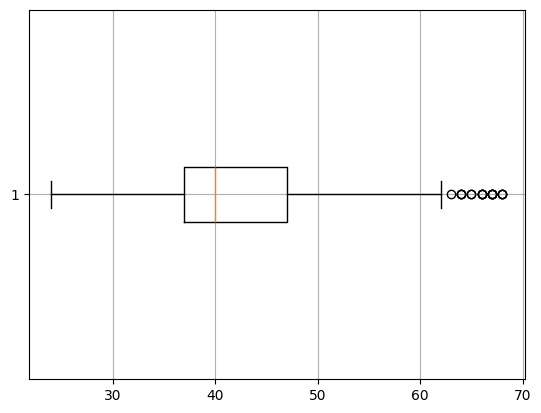

In [10]:
plt.boxplot(rewards, vert=False)
plt.grid()
plt.show()

In [11]:
print('mean reward:', np.mean(rewards))

mean reward: 41.993


### Neural Network Policy

Now we try a more sophisticated policy: let's use a neural network.

The network will take **state as input**. The output node will contain the probability of the actions.

Since there are two actions (left, right), we require one output node.  
Node will output probability of right (so prob of left is implied).

For simplicity, we will use one hidden layer.

Number of nodes in hidden layer is a hyperparameter.

---


#### 1) **Define a neural network model for the policy.**

**(POINTS: 1)**  
It should have appropriate dimensions for the input and output layer. Print a summary of the model that shows the output shape for each layer.

In [12]:
import torch
import torch.nn as nn

In [13]:
class CartPoleNN(nn.Module):
    def __init__(self):
        super(CartPoleNN, self).__init__()
        # input of 4 state components, hidden layer with 128 nodes, output of 1 action probability
        self.fc1 = nn.Linear(4, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [14]:
policy_model = CartPoleNN()
print(policy_model)

CartPoleNN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


#### 2) Is **REINFORCE** a Monte Carlo method? Explain your answer.

**(POINTS: 1)**

Yes, because it samples complete episodes and estimates the average estimated reward from a sequence of these episodes. This is similar to Monte Carlo methods whose biggest downside is the slow convergence. REINFORCE also is on-policy which means the model it's using to collect the data is the same one that is updated and optimized over time.



#### 3) **Training and Evaluating the Policy Model.**

Define functions to train and evaluate the model. Your work should include the steps below among others. Note that subtasks are numbered [1], [2], etc. and are worth one point each.

- **(POINTS: 2)** Write a function `play_single_step` to evolve the system one step. It should also compute the gradient of the loss function. Test that it works properly and print the next state.  

- **(POINTS: 2)** Write a function that runs multiple episodes, calling the `play_single_step` function. It should also compute and store the reward and gradient for each time step of each episode. Test that it works properly and print the rewards from running two episodes each with five time steps.
- **(POINTS: 3)** Define and run a training loop using the REINFORCE algorithm that [1] runs multiple episodes, [2] computes discounted rewards, and [3] updates the parameters with gradient ascent. Run a sufficient number of episodes and time steps to see an average reward of at least 75 in the `evaluate` step that follows. Show evidence that the training loop is working, such as printing the total discounted rewards per episode.
- **(POINTS: 3)** Now that the model is trained, you can use it as the policy and evaluate performance. Write code that [1] applies the model as the policy, [2] runs 1000 episodes and [3] computes the minimum reward, average reward, and maximum reward across the episodes. Discuss how the average reward from REINFORCE compares to the average reward from the simple policy from Cart Pole lab 1.

---

In [15]:
env = gym.make("CartPole-v1", render_mode = "rgb_array")
state = env.reset(seed=314)[0]
state

array([0.04225422, 0.02126478, 0.02520455, 0.00700802], dtype=float32)

Single step
- Note: In REINFORCE (or policy gradient methods in general), loss is computed at the end of episodes not steps, so I will return the log probability here and calculate the loss in the multiple episode function.

In [17]:
# play_single_step

def play_single_step(prev_state):
    # get the probability of moving right given the state
    action_probs = policy_model(torch.tensor(prev_state, dtype=torch.float32))
    # sample action using the probability
    sampling_dist = torch.distributions.Bernoulli(probs=action_probs)
    action = sampling_dist.sample()

    # take step in environment
    state, reward, terminated, truncated, info = env.step(int(action.item()))

    # get log probability of the action sampled
    log_prob = sampling_dist.log_prob(action)
    done = terminated or truncated

    return state, reward, log_prob, done

In [18]:
state = env.reset(seed=314)[0]
play_single_step(state)

(array([ 0.04267951, -0.1742094 ,  0.02534471,  0.30753553], dtype=float32),
 1.0,
 tensor([-0.5095], grad_fn=<NegBackward0>),
 False)

Multiple steps

In [19]:
# play_multiple_steps
def play_multiple_steps(num_episodes=100, num_steps_per_episode=500):
    episode_data = []

    # loop through number of episodes
    for episode in range(num_episodes):
      rewards = []
      log_probs = []
      states = []

      prev_state = env.reset()[0]
      states.append(prev_state)
      done = False
      steps = 0

      while not done and steps < num_steps_per_episode:
          state, reward, log_prob, done = play_single_step(prev_state)
          rewards.append(reward)
          log_probs.append(log_prob)
          states.append(state)
          prev_state = state
          steps += 1

      episode_data.append((states, rewards, log_probs))

    return episode_data

In [20]:
state = env.reset()[0]
episodes = play_multiple_steps(num_episodes=2, num_steps_per_episode=5)
for episode_idx, (states, rewards, log_probs) in enumerate(episodes):
    print(f"Episode {episode_idx+1}:")
    print(f"  States: {states}")
    print(f"  Rewards: {rewards}")
    print(f"  Log Probabilities: {log_probs}\n")

Episode 1:
  States: [array([ 0.04020622,  0.00272582, -0.01457915,  0.01914883], dtype=float32), array([ 0.04026073,  0.19805379, -0.01419617, -0.2780981 ], dtype=float32), array([ 0.04422181,  0.00313721, -0.01975813,  0.01007378], dtype=float32), array([ 0.04428455, -0.1916959 , -0.01955666,  0.2964579 ], dtype=float32), array([ 0.04045064, -0.38653368, -0.0136275 ,  0.58290935], dtype=float32), array([ 0.03271996, -0.5814621 , -0.00196931,  0.87126845], dtype=float32)]
  Rewards: [1.0, 1.0, 1.0, 1.0, 1.0]
  Log Probabilities: [tensor([-0.9169], grad_fn=<NegBackward0>), tensor([-0.5061], grad_fn=<NegBackward0>), tensor([-0.5103], grad_fn=<NegBackward0>), tensor([-0.5122], grad_fn=<NegBackward0>), tensor([-0.5187], grad_fn=<NegBackward0>)]

Episode 2:
  States: [array([0.02427474, 0.03036005, 0.0107139 , 0.03906071], dtype=float32), array([ 0.02488194,  0.22532673,  0.01149512, -0.2502227 ], dtype=float32), array([ 0.02938848,  0.42028266,  0.00649066, -0.53925776], dtype=float32), a

Training

In [43]:
# training loop
def training_loop(policy, num_episodes=100, num_steps_per_episode=500, learning_rate=0.001, discount_rate=0.99):
    optimizer = torch.optim.Adam(policy.parameters(), lr=learning_rate)

    total_rewards_per_episode = []  # Store raw episode rewards

    # run multiple episodes
    for episode in range(num_episodes):
        states, rewards, log_probs = play_multiple_steps(num_episodes=1, num_steps_per_episode=num_steps_per_episode)[0]

        # compute discounted rewards
        discounted_rewards = []
        cumulative_reward = 0
        for reward in reversed(rewards):
            cumulative_reward = reward + cumulative_reward * discount_rate
            discounted_rewards.insert(0, cumulative_reward)

        discounted_rewards = torch.tensor(discounted_rewards, dtype=torch.float32)
        log_probs = torch.cat(log_probs)

        # gradient ascent
        loss = -torch.mean(discounted_rewards * log_probs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # store the last discounted reward calculated
        total_rewards_per_episode.append(discounted_rewards[0])

        if episode % 50 == 0:
            print(f"Episode {episode}, Discounted Reward: {discounted_rewards[0]:.2f}")

    # torch.save(policy_model.state_dict(), 'policy_model.pth')

    return policy, np.mean(total_rewards_per_episode)  # Use raw rewards, not discounted


In [44]:
policy_model = CartPoleNN()
trained_policy, avg_reward_per_episode = training_loop(policy=policy_model, num_episodes=1000, num_steps_per_episode=500)

Episode 0, Discounted Reward: 14.85
Episode 50, Discounted Reward: 26.77
Episode 100, Discounted Reward: 12.25
Episode 150, Discounted Reward: 24.53
Episode 200, Discounted Reward: 11.36
Episode 250, Discounted Reward: 18.21
Episode 300, Discounted Reward: 13.13
Episode 350, Discounted Reward: 15.71
Episode 400, Discounted Reward: 41.88
Episode 450, Discounted Reward: 36.38
Episode 500, Discounted Reward: 43.04
Episode 550, Discounted Reward: 53.41
Episode 600, Discounted Reward: 37.65
Episode 650, Discounted Reward: 22.22
Episode 700, Discounted Reward: 84.73
Episode 750, Discounted Reward: 81.52
Episode 800, Discounted Reward: 81.14
Episode 850, Discounted Reward: 96.30
Episode 900, Discounted Reward: 86.33
Episode 950, Discounted Reward: 77.18


In [45]:
# evaluate policy performance
def evaluate_policy_performance(policy, num_episodes=1000):
    # set trained policy as model
    trained_model = policy

    rewards = []

    # run 1000 episodes
    for episode in range(num_episodes):
        state = env.reset(seed=np.random.randint(0,10000))[0]
        total_reward = 0
        done = False
        steps = 0

        # run until done or completed 500 episodes
        while not done:
            steps += 1
            with torch.no_grad():
                action_prob = trained_model(torch.tensor(state, dtype=torch.float32))
            action = 0 if action_prob < 0.5 else 1

            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    # calculate min, avg, max rewards
    min_reward = np.min(rewards)
    avg_reward = np.mean(rewards)
    max_reward = np.max(rewards)

    return min_reward, avg_reward, max_reward

In [47]:
min_reward, avg_reward, max_reward = evaluate_policy_performance(policy=trained_policy, num_episodes=1000)
print("Minimum Reward:", min_reward)
print("Average Reward:", avg_reward)
print("Maximum Reward:", max_reward)

Minimum Reward: 336.0
Average Reward: 479.308
Maximum Reward: 500.0


With the high average reward here, and an average reward of about 42 for the simple policy at the top of this notebook, there is a clear increase in performance by using this more advanced policy gradient method. In my initial cartpole lab, I was able to get a simple policy to reach 500 time steps nearly every time, but I think this neural net approach would perform better long term with enough training given. The higher complexity using the REINFORCE method here allows for the reinforcement learning policy to remember many different possibilities to keep the pole up as long as needed.